In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
def load_data():
    df=pd.read_csv(r"https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
    cols=[
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year',
        'fuel_efficiency_mpg'
    ]
    df=df.loc[:,cols].copy()
    return df

df=load_data()
df.sample(3)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6366,1770,202.0,3550,1996,32.2
9628,2440,286.0,4500,2013,26.3
5916,1990,217.0,3530,1986,32.4


Null values per column:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64



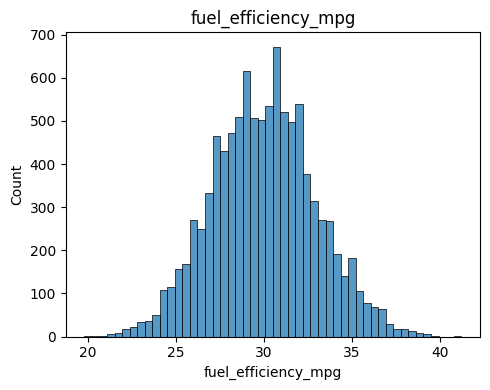

The median of horsepower is 254.0


In [14]:
# ---------------------------------------------------------------------------
# 2. Exploratory data analysis (lesson 03)
# ---------------------------------------------------------------------------

def eda(df):
    print('Null values per column:')
    print(df.isnull().sum())
    print()
    
    fig, ax = plt.subplots(1,  figsize=(5, 4))
    sns.histplot(df.fuel_efficiency_mpg, bins=50, ax=ax).set_title('fuel_efficiency_mpg')
    plt.tight_layout()
    plt.show()

    horsepower_median= df.horsepower.median()
    print(f"The median of horsepower is {horsepower_median}")


eda(df)

In [15]:
# ---------------------------------------------------------------------------
# 3. Prepare and split the dataset
# ---------------------------------------------------------------------------
def split_data(df, seed):
    
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    # Shuffle the records in a reproducible way
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    # Target variable
    y_train = df_train.fuel_efficiency_mpg.values
    y_val =   df_val.fuel_efficiency_mpg.values
    y_test =  df_test.fuel_efficiency_mpg.values

    # Drop the target from the features so it is not used as an input
    del df_train["fuel_efficiency_mpg"]
    del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]

    return df_train, df_val, df_test, y_train, y_val, y_test

SEED=42
df_train, df_val, df_test, y_train, y_val, y_test=split_data(df, SEED)

In [16]:
# ---------------------------------------------------------------------------
# 4. Linear regression: normal equation w = (XᵀX)⁻¹Xᵀy
# ---------------------------------------------------------------------------
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def predict(X, w0, w):
    return w0 + X.dot(w)


# ---------------------------------------------------------------------------
# 5. RMSE
# ---------------------------------------------------------------------------

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)


# ---------------------------------------------------------------------------
# 6. Building the X matrix
# ---------------------------------------------------------------------------

BASE = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def prepare_X(df, fill_value=0):
    df_num = df[BASE].fillna(fill_value)
    return df_num.values

### Question 3: filling `horsepower` with 0 vs. with the mean (from train)

In [17]:
# Option 1: fill with 0
X_train = prepare_X(df_train, fill_value=0)
X_val = prepare_X(df_val, fill_value=0)
w0, w = train_linear_regression(X_train, y_train)
score_zero = rmse(y_val, predict(X_val, w0, w))

# Option 2: fill with the mean, computed ONLY from train
mean_hp = df_train.horsepower.mean()
X_train = prepare_X(df_train, fill_value=mean_hp)
X_val = prepare_X(df_val, fill_value=mean_hp)
w0, w = train_linear_regression(X_train, y_train)
score_mean = rmse(y_val, predict(X_val, w0, w))

print('Mean of horsepower (train):', mean_hp)
print('RMSE with 0:   ', round(score_zero, 3))
print('RMSE with mean:', round(score_mean, 3))

Mean of horsepower (train): 254.46338337605272
RMSE with 0:    2.205
RMSE with mean: 2.202


### Question 4: regularized regression (NAs filled with 0)

In [18]:
X_train = prepare_X(df_train, fill_value=0)
X_val = prepare_X(df_val, fill_value=0)

scores_r = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    score = rmse(y_val, predict(X_val, w0, w))
    scores_r[r] = round(score, 4)
    print(r, round(w0, 4), round(score, 4))

# Best r (in case of a tie, the smallest one)
best_rmse = min(scores_r.values())
best_r = min(r for r, s in scores_r.items() if s == best_rmse)
print()
print('Best r:', best_r, '-> RMSE', best_rmse)

0 -153.885 2.2053
0.01 -148.3092 2.2058
0.1 -111.8387 2.2241
1 -32.3319 2.3492
5 -7.7729 2.4094
10 -3.9871 2.4195
100 -0.4082 2.4292

Best r: 0 -> RMSE 2.2053


### Question 5: effect of the seed (NAs filled with 0, no regularization)

In [19]:
scores_seed = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_tr, df_va, df_te, y_tr, y_va, y_te = split_data(df, seed)

    X_tr = prepare_X(df_tr, fill_value=0)
    X_va = prepare_X(df_va, fill_value=0)
    w0, w = train_linear_regression(X_tr, y_tr)
    score = rmse(y_va, predict(X_va, w0, w))
    scores_seed.append(score)
    print(seed, round(score, 4))

std = np.std(scores_seed)
print()
print('Standard deviation:', round(std, 3))

0 2.2392
1 2.2021
2 2.1634
3 2.2044
4 2.2019
5 2.2458
6 2.2697
7 2.1908
8 2.2166
9 2.207

Standard deviation: 0.029


### Question 6: final model with seed 9, train + val, r=0.001

In [20]:
df_tr, df_va, df_te, y_tr, y_va, y_te = split_data(df, 9)

df_full_train = pd.concat([df_tr, df_va]).reset_index(drop=True)
y_full_train = np.concatenate([y_tr, y_va])

X_full_train = prepare_X(df_full_train, fill_value=0)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_te = prepare_X(df_te, fill_value=0)
score_test = rmse(y_te, predict(X_te, w0, w))
print('RMSE on test:', round(score_test, 3))

RMSE on test: 2.236
